인공 신경망 모델 훈련하는 사례 / 필요한 도구 알기

# 손실 곡선
- 케라스의 fit() 메서드는 History 객체를 리턴
  - 계산 지표, 손실, 정확도 값 저장

In [2]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [5]:
# 모델 만드는 함수
def model_fn(a_layer = None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu')) # 밀
    if a_layer:
        model.add(a_layer) # 은닉층 뒤에 매개변수로 전달된 층 추가
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
    return model

In [6]:
model = model_fn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=5, verbose=0) # verbose: 훈련 과정 출력 조절. 0(훈련 과정 나타내지 않음), 1(에포크마다 진행 막대, 손실 등 지표 출력), 2(진행 막대 빼고 출력)

In [ ]:
print(history.history.keys()) # accuracy와 loss에는 각 에포크마다의 값이 나열되어 있음

dict_keys(['accuracy', 'loss'])


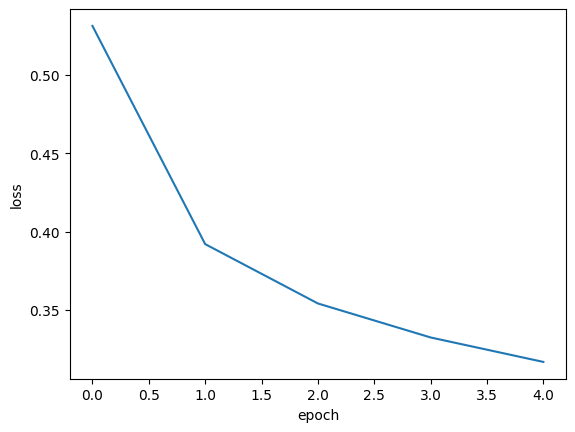

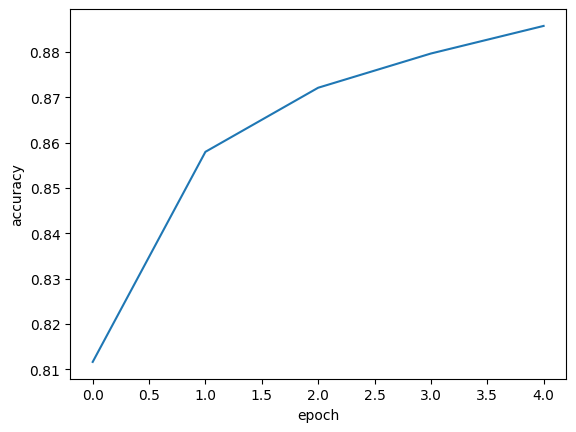

In [9]:
import matplotlib.pyplot as plt

# 에포크 당 손실
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

# 에포크 당 정확도
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

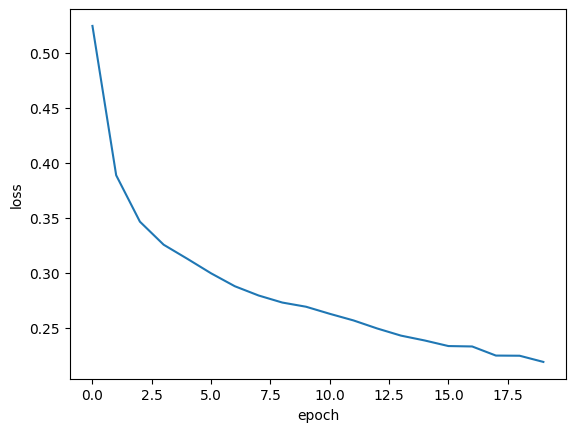

In [10]:
# 에포크 늘려서 훈련하고 손실 그려보기
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

# 검증 손실
- 에포크에 따른 과대/과소적합을 판단하려면 훈련 세트, 테스트 세트 모두에 대한 점수 필요
- 이때, 정확도가 아닌 **손실**을 사용해 점수를 계산
  - 인공 신경망 모델이 최적화하는 대상이 손실 함수이기 때문

In [11]:
# 에포크마다 검증 손실 계산
# fit() 메서드에 검증 데이터 전달
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target)) # 검증 데이터 전달

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


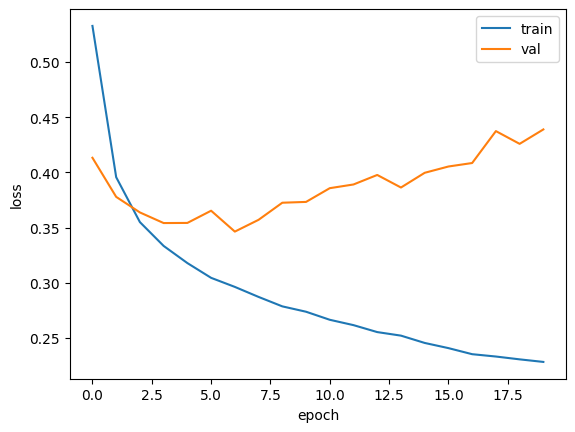

In [12]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

- 훈련 손실은 계속 내려감 -> 과대적합 모델 만들어짐
- 검증 손실은 내려가다가 올라감
  - 상승하는 시점을 최대한 늦추면 **검증 세트 손실 감소 & 정확도 증가**

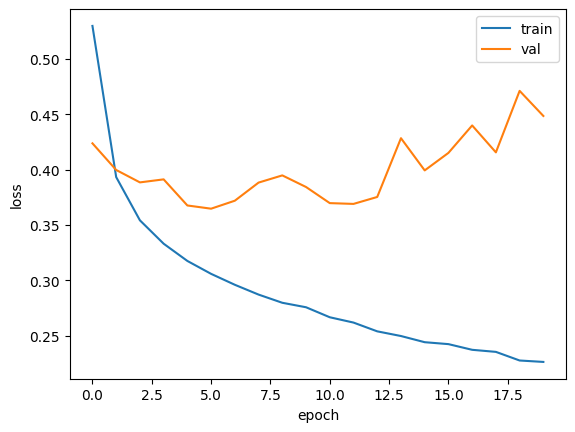

In [13]:
# 옵티마이저 하이퍼파라미터 조정을 통해 과대적합 완화

model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# 신경망 규제
### 드롭아웃(dropout)
- 훈련 과정에서 층에 있는 일부 뉴런을 랜덤하게 꺼서(출력을 0으로 만들어) 과대적합 막는 것
  - 이전 층의 일부 뉴런이 랜덤하게 꺼짐 -> 특정 뉴런에 과대하게 의존하는 것을 줄임
  - 또한 모든 입력에 주의를 기울여야 함 -> 일부 뉴런이 꺼진다고 생각하면 더 안정적인 예측을 만듦
- 드롭아웃 시킬 뉴런 개수 -> 하이퍼파라미터
- 훈련 끝나고 평가/예측할 때는 드롭아웃 적용하면 안 됨
  - 훈련된 모든 뉴런 사용해야 올바른 예측 수행
  - cf) 케라스는 알아서 드롭아웃 적용 안 함

In [14]:
# 뉴런 드롭아웃
# 어떤 층 뒤에 드롭아웃을 두어 출력을 랜덤하게 0으로 만듦
# 층처럼 사용되지만 모델 파라미터는 없음
# 이전 Flatten 층과 비슷

model = model_fn(keras.layers.Dropout(0.3))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

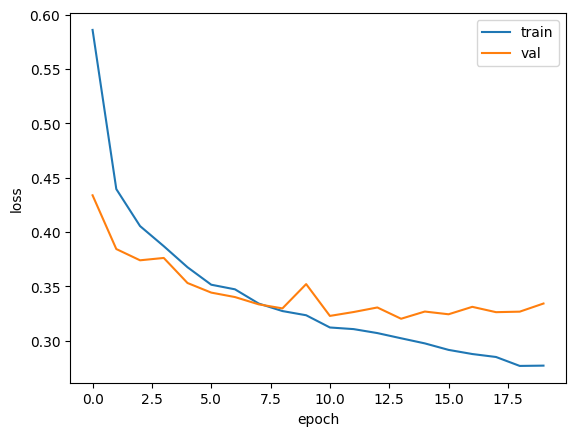

In [15]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

- 둘의 손실률 차이가 줄어들면서 과대적합이 줄어듦

# 모델 저장과 복원


In [16]:
# 에포크 횟수 11로 다시 지정하고 훈련
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=11, verbose=0, validation_data=(val_scaled, val_target))

In [17]:
# 케라스 -> 모델 구조와 파라미터 저장
model.save('model-whole.keras')

# 훈련된 모델의 파라미터만 저장
model.save_weights('model.weights.h5')

In [18]:
!ls -al model*

-rw-r--r-- 1 root root 976600 Jan 12 11:08 model.weights.h5
-rw-r--r-- 1 root root 979409 Jan 12 11:08 model-whole.keras


In [ ]:
# 훈련 안 한 모델에 저장된 파라미터 읽어서 사용하기
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('model.weights.h5') # save_weights로 저장한 모델과 정확히 같은 구조를 가져야 함

In [ ]:
# 모델 검증 정확도 확인
# 샘플마다 10개의 클래스에 대한 확률 반환

# 10개 확률 중 가장 큰 값의 인덱스를 골라 타깃 레이블과 비교해 정확도 계산
import numpy as np

# np.argmax: 배열에서 가장 큰 값의 인덱스 리턴
# axis=-1: 배열의 마지막 차원을 따라 최댓값 고름
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
0.8844166666666666


In [21]:
# 모델 전체 파일에서 읽은 후 검증 세트 정확도 출력
model = keras.models.load_model('model-whole.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8891 - loss: 0.3158


[0.3164580464363098, 0.8844166398048401]

# 콜백
- 훈련 과정 중간에 어떤 작업을 수행할 수 있게 하는 케라스 객체
- fit() 메서드의 callbacks 매개변수에 리스트로 전달해 사용
- ModelCheckpoint 콜백: 기본적으로 에포크마다 모델 저장
  - save_best_only=True 매개변수: 가장 낮은 검증 손실 만드는 모델 저장

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True) # 에포크마다 모델 저장 -> 가장 낮은 검증 손실 모델 자동으로 저장해줌
model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb])

In [23]:
# 위에서 저장한 최상의 검증 점수 모델 읽어서 예측 수행
model = keras.models.load_model('best-model.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8905 - loss: 0.3125


[0.3140798807144165, 0.887499988079071]

In [24]:
# 검증 점수가 상승하기 시작하면 그 이후부터는 과대적합이 커짐
# 이 이상 훈련 지속하는 건 낭비 -> 조기 종료(early stopping) 필요
# 훈련 에포크 횟수 제한하는 역할이지만 모델이 과대적합되는 걸 막아줌 -> 규제 방법 중 하나로도 생각 가능

# 케라스 조기 종료 콜백 -> EarlyStopping
# patience 매개변수: 검증 점수 향상되지 않더라도 참을 에포크 횟수. 연속으로 검증 점수 향상되지 않으면 훈련 중지
# restore_best_weights 매개변수: 가장 낮은 검증 손실을 낸 모델 파라미터로 되돌림

# EarlyStopping 콜백 + ModelCheckpoint 콜백 => 가장 낮은 검증 손실의 모델 파일에 저장 & 검증 손실이 다시 상승할 때 훈련 중지
# 또한 훈련 중지한 다음 현재 모델 파라미터 -> 최상의 파라미터로 되돌림

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True) # 가장 낮은 검증 손실 모델 저장
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True) # 최대 연속 2번, 훈련 종료 후 최상 파라미터로 되돌림
history = model.fit(train_scaled, train_target, epochs=20, verbose=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20


In [25]:
print(early_stopping_cb.stopped_epoch)

9


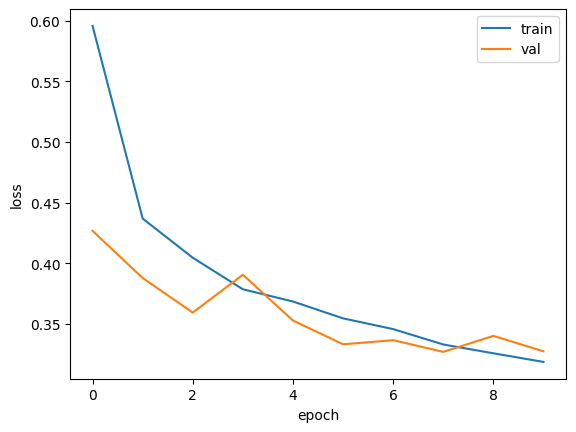

In [26]:
# 훈련 손실, 검증 손실 출력해 확인
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [27]:
# 조기 종료로 얻은 모델로 검증 세트 성능 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8853 - loss: 0.3246


[0.32694211602211, 0.8845000267028809]